In [3]:
# Nécessaire de run 2 fois cette cellule pour ne pas avoir de message d'erreur
import IPython.extensions.autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# import my method from the source code
from src.ingest import data_workflow
from src.dataset import analyze, detect_elapsed_time_anomalies, resample
import matplotlib.pyplot as plt

count                        22503
mean     0 days 00:00:11.515798249
std      0 days 00:00:44.245820812
min         0 days 00:00:01.001000
25%         0 days 00:00:03.005000
50%         0 days 00:00:06.997000
75%         0 days 00:00:09.998000
max         0 days 00:49:56.007000
Name: timestamp_diff_col, dtype: object
---------------- elapsed anomalies : 19412 (expected 0 days 00:00:02.003000) ------------


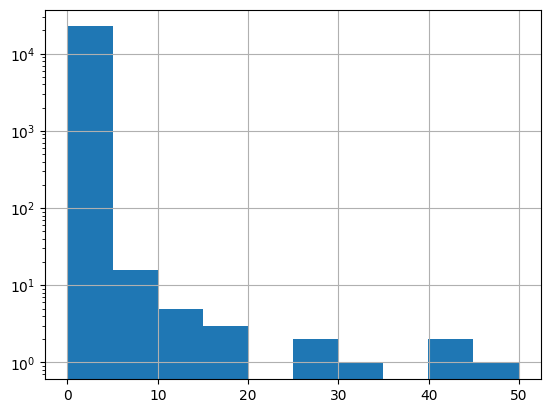

In [ ]:
df = data_workflow("inariz")

# include the unit into the main column name
df = df.rename(columns={"Valeur": "steam_production_m3_h"})

# for other columns, keep only numerical columns
# set the timestamp as a column with a standard name, not as the index
df = df.drop(columns=["Unité"])


analyze(df)
elapsed_anomalies, expected_delta = detect_elapsed_time_anomalies(df, timestamp_col="measured_at_utc")
# target
df = df[["measured_at_utc", "steam_production_m3_h"]] #required, as the data_workflow creates new columns when localizing and converting to utc
df_10min = resample(df, desired_timedelta="10min", aggregate_function="mean")
df_15min = resample(df, desired_timedelta="15min", aggregate_function="mean")
# fill the nan values with a 0
df_10min["steam_production_m3_h"] = df_10min["steam_production_m3_h"].fillna(0)
df_15min["steam_production_m3_h"] = df_15min["steam_production_m3_h"].fillna(0)

Verify that the average is done correctly between [00:00; 00:15[

In [42]:
import pandas as pd 
df_15min[(df_15min["measured_at_utc"] >= pd.Timestamp(2025, 12, 15, 0, 0, 0, tz="UTC")) & (df_15min["measured_at_utc"] <= pd.Timestamp(2025, 12, 15, 1, 0, 0, tz="UTC"))]

,measured_at_utc,steam_production_(m3/h)
4,2025-12-15 00:00:00+00:00,350.557155
5,2025-12-15 00:15:00+00:00,210.832194
6,2025-12-15 00:30:00+00:00,694.924794
7,2025-12-15 00:45:00+00:00,532.643122
8,2025-12-15 01:00:00+00:00,631.676072


In [ ]:
min(df["steam_production_m3_h"])

11.251571

In [46]:
df[(df["measured_at_utc"] >= pd.Timestamp(2025, 12, 15, 0, 15, 0, tz="UTC")) & (df["measured_at_utc"] < pd.Timestamp(2025, 12, 15, 0, 30, 0, tz="UTC"))]["steam_production_(m3/h)"].describe()

count     76.000000
mean     210.832194
std       72.323694
min       62.002769
25%      153.867065
50%      246.758553
75%      258.700127
max      458.215576
Name: steam_production_(m3/h), dtype: float64

In [ ]:
# plot original and resampled timeseries, to check the choice of aggregate_function
import PyQt6
%matplotlib qt
fig, ax = plt.subplots()

ax.plot(df["measured_at_utc"], df["steam_production_m3_h"], label="original")
ax.step(df_10min["measured_at_utc"], df_10min["steam_production_m3_h"], label="resampled 10 min", where="post")
ax.step(df_15min["measured_at_utc"], df_15min["steam_production_m3_h"], label="resampled 15 min", where="post")
ax.set_ylabel("Value")
# ax.set_title(path.name)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Try simplest forms of prediction

In [ ]:
from src.predict import simple_copy

df_copy1day = simple_copy(df_15min, "measured_at_utc", "steam_production_m3_h", pd.Timestamp(2025,12,15,0,0,0, tz="UTC"), pd.Timestamp(2025,12,16,0,0,0, tz="UTC"))
df_copy1week = simple_copy(df_15min, "measured_at_utc", "steam_production_m3_h", pd.Timestamp(2025,12,15,0,0,0, tz="UTC"), pd.Timestamp(2025,12,20,0,0,0, tz="UTC"))


TEMP verification pour simple_copy

In [ ]:
start = pd.Timestamp(2025,12,15, tz="Europe/Paris").tz_convert("UTC")
print(start)
df_copy1day[df_copy1day["measured_at_utc"]==start]

,measured_at,steam_production_(m3/h)
0,2025-12-14 23:00:00+00:00,675.168389


In [ ]:
df_copy1day.iloc[-100:-90].measured_at_utc.dt.weekday

511    5
512    5
513    5
514    5
515    5
516    5
517    5
518    6
519    6
520    6
Name: measured_at, dtype: int32

In [ ]:
# df_copy1week[df_copy1week.measured_at_utc == start_new_1week]
# df_copy1week.iloc[len(df_15min)-3:len(df_15min)+3]
print(df_copy1week.iloc[len(df_15min)].measured_at_utc.weekday())

start = pd.Timestamp(2025,12,15, tz="Europe/Paris").tz_convert("UTC")

print(df_15min[df_15min.measured_at_utc == start].measured_at_utc.dt.weekday)


6
0    6
Name: measured_at, dtype: int32


temp vérification copy median

In [12]:

from src.predict import copy_median_values

# df_median1day = copy_median_values(df_15min, "measured_at_utc", "steam_production_m3_h", respect_holidays=False, respect_weekdays=True, respect_time=True, extension="jour")
df_median1week = copy_median_values(df_15min, "measured_at_utc", "steam_production_m3_h", respect_holidays=False, respect_weekdays=True, respect_time=True, extension="semaine")

# df_median1day.iloc[len(df_15min)-3:len(df_15min)+3]

In [108]:
df_median1week[(df_median1week["measured_at_utc"] >= pd.Timestamp(2026, 2, 13, 12, tz="UTC"))&(df_median1week["measured_at_utc"] <= pd.Timestamp(2026, 2, 14, 0, tz="UTC"))]

,measured_at_utc,steam_production_(m3/h)
436,2026-02-13 12:00:00+00:00,634.888333
437,2026-02-13 12:15:00+00:00,634.888333
438,2026-02-13 12:30:00+00:00,634.888333
439,2026-02-13 12:45:00+00:00,634.888333
440,2026-02-13 13:00:00+00:00,634.888333
441,2026-02-13 13:15:00+00:00,634.888333
442,2026-02-13 13:30:00+00:00,634.888333
443,2026-02-13 13:45:00+00:00,634.888333
444,2026-02-13 14:00:00+00:00,634.888333
445,2026-02-13 14:15:00+00:00,634.888333


In [74]:
for ts in [df, df_15min, df_median1week]:
    print(len(ts), min(ts["measured_at_utc"]), max(ts["measured_at_utc"]))

22504 2026-02-08 23:00:00+00:00 2026-02-11 22:59:00.008000+00:00
288 2026-02-08 23:00:00+00:00 2026-02-11 22:45:00+00:00
960 2026-02-08 23:00:00+00:00 2026-02-18 22:45:00+00:00


In [ ]:
# plot original and resampled and extended timeseries, to check the choice of aggregate_function
import PyQt6
%matplotlib qt
fig, ax = plt.subplots()

ax.plot(df["measured_at_utc"], df["steam_production_m3_h"], label="original")
ax.step(df_15min["measured_at_utc"], df_15min["steam_production_m3_h"], label="resampled 15 min", where="post")
ax.step(df_median1week["measured_at_utc"], df_median1week["steam_production_m3_h"], label="extended 15 min", where="post")
ax.set_ylabel("Value")
# ax.set_title(path.name)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

copy_median_value copie forcément juste après la fin du df inial
ce que je dois vérifier, c'est si, pour faire la valeur du 2025-12-20 07:30:00+00:00, il a bien pris la mediane des jours et weekdays et créneaux pertinents.

# calcul des market orders

In [15]:
from src.market_orders import build_market_orders
from src.utils import load_config, convert_saturated_steam_units

config = load_config()
project = "inariz"

# convert m3/h to m3
df_median1week["steam_production_m3"] = df_median1week["steam_production_m3_h"] * 15/60 
# fait partie des checks à faire
# je pense que c'est faux, mais pas grave pour l'instant, todo corriger
# je ne sais pas si ce que je calcule là est sur la base de la vapeur ou du gaz
df_median1week = convert_saturated_steam_units(
    df_median1week,
    "steam_production_m3",
    "steam_production_kwhth",
    "m3",
    "kWh th"
)

paths = build_market_orders(
    project_name=project,
    forecast=df_median1week,  # output de simple_copy / copy_median_values
    prix_seuil_euro_mwh=config[project]["prix_seuil_euro_mwh"][0],
    puissance_chaudiere_elec_mw=config[project]["puissance_chaudiere_elec_mw"],
    capacite_min_gaz_kwhth=config[project]["capacite_min_gaz_kwhth"],
    # timestamp_col="measured_at_utc",  # optionnel si non détectable
    value_col="steam_production_kwhth",  # optionnel si non détectable
)
print(paths)


[WindowsPath('data/market_orders/inariz_20260208_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260209_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260210_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260211_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260212_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260213_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260214_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260215_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260216_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260217_20260224_1823.csv'), WindowsPath('data/market_orders/inariz_20260218_20260224_1823.csv')]
